# Entity Masking Experiment

## Objective
Test whether masking named entities (PERSON, ORG) reduces model reliance on spurious correlations like "Trump", "Clinton", "Obama" and improves generalization.

## Approach
1. Use spaCy NER to identify PERSON and ORG entities
2. Replace entities with generic tokens [PERSON] and [ORG]
3. Train Logistic Regression on both original and masked text
4. Compare feature importance and accuracy


## Part 1: Setup and Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load spaCy for NER
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
    print("✓ spaCy model loaded: en_core_web_sm")
except OSError:
    print("Downloading spaCy model...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")
    print("✓ spaCy model downloaded and loaded")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ All imports successful")


✓ spaCy model loaded: en_core_web_sm
✓ All imports successful


In [2]:
# Load data
project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"

print("Loading data...")
train_df = pd.read_csv(processed_dir / "train.csv")
test_df = pd.read_csv(processed_dir / "test.csv")

# Handle NaN values
train_df['text'] = train_df['text'].fillna('').astype(str)
test_df['text'] = test_df['text'].fillna('').astype(str)

print(f"Train samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Columns: {train_df.columns.tolist()}")


Loading data...
Train samples: 35,551
Test samples: 8,888
Columns: ['id', 'title', 'text', 'label']


## Part 2: Entity Masking Function


In [3]:
def mask_entities(text, entity_types=["PERSON", "ORG"]):
    """
    Replace PERSON and ORG entities with generic [PERSON] and [ORG] tokens.
    
    Args:
        text: Input text string
        entity_types: List of spaCy entity types to mask
        
    Returns:
        Tuple of (masked_text, entity_counts_dict)
    """
    if not text or len(text.strip()) == 0:
        return text, {}
    
    # Limit text length for spaCy processing (very long texts can be slow)
    max_len = 100000
    if len(text) > max_len:
        text = text[:max_len]
    
    try:
        doc = nlp(text)
    except Exception as e:
        return text, {}
    
    masked = text
    entity_counts = {etype: 0 for etype in entity_types}
    
    # Process entities in reverse order to preserve character indices
    for ent in reversed(doc.ents):
        if ent.label_ in entity_types:
            masked = masked[:ent.start_char] + f"[{ent.label_}]" + masked[ent.end_char:]
            entity_counts[ent.label_] += 1
    
    return masked, entity_counts

# Test the function
test_text = "Donald Trump met with Hillary Clinton and representatives from Google and Facebook yesterday."
masked_text, counts = mask_entities(test_text)
print("Original:", test_text)
print("Masked:  ", masked_text)
print("Counts:  ", counts)


Original: Donald Trump met with Hillary Clinton and representatives from Google and Facebook yesterday.
Masked:   [PERSON] met with [PERSON] and representatives from [ORG] and Facebook yesterday.
Counts:   {'PERSON': 2, 'ORG': 1}


## Part 3: Apply Masking to Dataset


In [4]:
# Apply entity masking to training data
print("="*60)
print("APPLYING ENTITY MASKING TO TRAINING DATA")
print("="*60)

train_masked_texts = []
train_entity_counts = []

for text in tqdm(train_df['text'].values, desc="Masking train"):
    masked, counts = mask_entities(text)
    train_masked_texts.append(masked)
    train_entity_counts.append(counts)

train_df['text_masked'] = train_masked_texts
train_df['person_count'] = [c.get('PERSON', 0) for c in train_entity_counts]
train_df['org_count'] = [c.get('ORG', 0) for c in train_entity_counts]

print(f"\n✓ Training data masked")
print(f"  Total PERSON entities masked: {train_df['person_count'].sum():,}")
print(f"  Total ORG entities masked: {train_df['org_count'].sum():,}")
print(f"  Articles with entities: {(train_df['person_count'] + train_df['org_count'] > 0).sum():,}")


APPLYING ENTITY MASKING TO TRAINING DATA


Masking train: 100%|██████████| 35551/35551 [2:07:51<00:00,  4.63it/s]   


✓ Training data masked
  Total PERSON entities masked: 446,965
  Total ORG entities masked: 403,588
  Articles with entities: 34,888


In [6]:
# Apply entity masking to test data
print("="*60)
print("APPLYING ENTITY MASKING TO TEST DATA")
print("="*60)

test_masked_texts = []
test_entity_counts = []

for text in tqdm(test_df['text'].values, desc="Masking test"):
    masked, counts = mask_entities(text)
    test_masked_texts.append(masked)
    test_entity_counts.append(counts)

test_df['text_masked'] = test_masked_texts
test_df['person_count'] = [c.get('PERSON', 0) for c in test_entity_counts]
test_df['org_count'] = [c.get('ORG', 0) for c in test_entity_counts]

print(f"\n✓ Test data masked")
print(f"  Total PERSON entities masked: {test_df['person_count'].sum():,}")
print(f"  Total ORG entities masked: {test_df['org_count'].sum():,}")


APPLYING ENTITY MASKING TO TEST DATA


Masking test: 100%|██████████| 8888/8888 [08:47<00:00, 16.86it/s]


✓ Test data masked
  Total PERSON entities masked: 109,764
  Total ORG entities masked: 101,679


In [7]:
# Show before/after examples
print("="*60)
print("BEFORE/AFTER EXAMPLES")
print("="*60)

# Find articles with high entity counts
high_entity_idx = train_df[train_df['person_count'] + train_df['org_count'] > 5].index[:3]

for i, idx in enumerate(high_entity_idx):
    print(f"\n--- Example {i+1} (Label: {'Fake' if train_df.loc[idx, 'label'] == 1 else 'Real'}) ---")
    print(f"PERSON: {train_df.loc[idx, 'person_count']}, ORG: {train_df.loc[idx, 'org_count']}")
    print(f"\nOriginal (first 500 chars):")
    print(train_df.loc[idx, 'text'][:500])
    print(f"\nMasked (first 500 chars):")
    print(train_df.loc[idx, 'text_masked'][:500])


BEFORE/AFTER EXAMPLES

--- Example 1 (Label: Fake) ---
PERSON: 14, ORG: 12

Original (first 500 chars):
The Fake News About Central Banking By Daily Bell Staff - November 22, 2016 
Trump Shouldn’t Bully the Fed … U.S. President-elect Donald Trump repeatedly criticized Federal Reserve Chair Janet Yellen during his campaign. British Prime Minister Theresa May has questioned the Bank of England’s recent actions, for a while putting Governor Mark Carney’s tenure in doubt. The long-cherished principle of central-bank independence seems to be under attack. – Bloomberg 
The mainstream media is up in arms

Masked (first 500 chars):
[ORG] November 22, 2016 
[ORG] the [ORG] … U.S. President-elect [PERSON] repeatedly criticized [ORG] [PERSON] during his campaign. British Prime Minister [PERSON] has questioned [ORG] recent actions, for a while putting Governor [PERSON]’s tenure in doubt. The long-cherished principle of central-bank independence seems to be under attack. – [PERSON] 
The mainstream 

## Part 4: Create TF-IDF Features


In [8]:
# Prepare data
X_train_original = train_df['text'].values
X_train_masked = train_df['text_masked'].values
y_train = train_df['label'].values

X_test_original = test_df['text'].values
X_test_masked = test_df['text_masked'].values
y_test = test_df['label'].values

print("="*60)
print("CREATING TF-IDF FEATURES")
print("="*60)

# TF-IDF for original text (baseline)
print("\nCreating TF-IDF for ORIGINAL text...")
vectorizer_original = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf_original = vectorizer_original.fit_transform(X_train_original)
X_test_tfidf_original = vectorizer_original.transform(X_test_original)
print(f"  Original vocabulary size: {len(vectorizer_original.vocabulary_)}")

# TF-IDF for masked text (experiment)
print("\nCreating TF-IDF for MASKED text...")
vectorizer_masked = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf_masked = vectorizer_masked.fit_transform(X_train_masked)
X_test_tfidf_masked = vectorizer_masked.transform(X_test_masked)
print(f"  Masked vocabulary size: {len(vectorizer_masked.vocabulary_)}")

print("\n✓ TF-IDF features created for both original and masked text")


CREATING TF-IDF FEATURES

Creating TF-IDF for ORIGINAL text...
  Original vocabulary size: 5000

Creating TF-IDF for MASKED text...
  Masked vocabulary size: 5000

✓ TF-IDF features created for both original and masked text


## Part 5: Train Logistic Regression Models


In [9]:
print("="*60)
print("TRAINING LOGISTIC REGRESSION MODELS")
print("="*60)

# Model A: Original text (baseline)
print("\nTraining Model A (ORIGINAL text)...")
model_original = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_original.fit(X_train_tfidf_original, y_train)
y_pred_original = model_original.predict(X_test_tfidf_original)
acc_original = accuracy_score(y_test, y_pred_original)
print(f"  Accuracy: {acc_original:.4f}")

# Model B: Masked text (experiment)
print("\nTraining Model B (MASKED text)...")
model_masked = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_masked.fit(X_train_tfidf_masked, y_train)
y_pred_masked = model_masked.predict(X_test_tfidf_masked)
acc_masked = accuracy_score(y_test, y_pred_masked)
print(f"  Accuracy: {acc_masked:.4f}")

# Summary
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")
print(f"\nOriginal text model accuracy: {acc_original:.4f}")
print(f"Masked text model accuracy:   {acc_masked:.4f}")
print(f"Difference:                   {(acc_masked - acc_original)*100:+.2f}%")


TRAINING LOGISTIC REGRESSION MODELS

Training Model A (ORIGINAL text)...
  Accuracy: 0.9289

Training Model B (MASKED text)...
  Accuracy: 0.9290

MODEL COMPARISON

Original text model accuracy: 0.9289
Masked text model accuracy:   0.9290
Difference:                   +0.01%


In [10]:
# Detailed classification reports
print("="*60)
print("CLASSIFICATION REPORT: ORIGINAL TEXT MODEL")
print("="*60)
print(classification_report(y_test, y_pred_original, target_names=['Real', 'Fake']))

print("="*60)
print("CLASSIFICATION REPORT: MASKED TEXT MODEL")
print("="*60)
print(classification_report(y_test, y_pred_masked, target_names=['Real', 'Fake']))


CLASSIFICATION REPORT: ORIGINAL TEXT MODEL
              precision    recall  f1-score   support

        Real       0.94      0.95      0.95      5912
        Fake       0.90      0.88      0.89      2976

    accuracy                           0.93      8888
   macro avg       0.92      0.92      0.92      8888
weighted avg       0.93      0.93      0.93      8888

CLASSIFICATION REPORT: MASKED TEXT MODEL
              precision    recall  f1-score   support

        Real       0.94      0.95      0.95      5912
        Fake       0.91      0.88      0.89      2976

    accuracy                           0.93      8888
   macro avg       0.92      0.92      0.92      8888
weighted avg       0.93      0.93      0.93      8888



## Part 6: Feature Importance Analysis


In [11]:
def get_top_features(model, vectorizer, n=20):
    """Get top positive (fake) and negative (real) features"""
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_[0]
    
    top_fake_idx = np.argsort(coefs)[-n:][::-1]
    top_real_idx = np.argsort(coefs)[:n]
    
    top_fake = [(feature_names[i], coefs[i]) for i in top_fake_idx]
    top_real = [(feature_names[i], coefs[i]) for i in top_real_idx]
    
    return top_fake, top_real

# Get top features for both models
fake_original, real_original = get_top_features(model_original, vectorizer_original)
fake_masked, real_masked = get_top_features(model_masked, vectorizer_masked)

print("="*70)
print("TOP FEATURES: ORIGINAL TEXT MODEL")
print("="*70)
print("\nTop FAKE indicators:")
for feat, coef in fake_original[:15]:
    print(f"  {feat}: {coef:.3f}")
print("\nTop REAL indicators:")
for feat, coef in real_original[:15]:
    print(f"  {feat}: {coef:.3f}")


TOP FEATURES: ORIGINAL TEXT MODEL

Top FAKE indicators:
  2016: 6.686
  hillary: 6.538
  october: 6.276
  november: 5.039
  november 2016: 4.325
  president trump: 3.905
  com: 3.800
  watch: 3.800
  today: 3.672
  obama: 3.613
  entire: 3.532
  daily: 3.461
  anti: 3.393
  source: 3.329
  uk: 3.276

Top REAL indicators:
  said: -14.382
  president donald: -7.304
  thursday: -6.291
  tuesday: -5.820
  friday: -5.752
  monday: -5.633
  wednesday: -5.552
  mr: -4.934
  sunday: -4.533
  ms: -4.215
  reuters: -4.040
  said statement: -3.527
  told reuters: -3.359
  saturday: -3.358
  republican: -3.353


In [12]:
print("="*70)
print("TOP FEATURES: MASKED TEXT MODEL")
print("="*70)
print("\nTop FAKE indicators:")
for feat, coef in fake_masked[:15]:
    print(f"  {feat}: {coef:.3f}")
print("\nTop REAL indicators:")
for feat, coef in real_masked[:15]:
    print(f"  {feat}: {coef:.3f}")


TOP FEATURES: MASKED TEXT MODEL

Top FAKE indicators:
  october: 6.070
  2016: 5.968
  november: 4.994
  watch: 4.401
  november 2016: 4.358
  obama: 4.302
  today: 3.672
  entire: 3.485
  america: 3.405
  just: 3.210
  anti: 3.156
  https: 2.953
  stated: 2.951
  source: 2.935
  reportedly: 2.861

Top REAL indicators:
  said: -12.950
  thursday: -6.342
  tuesday: -6.138
  friday: -5.877
  monday: -5.702
  wednesday: -5.696
  president person: -5.199
  sunday: -4.533
  republican: -4.193
  saturday: -3.586
  said thursday: -3.431
  ms person: -3.427
  reporters: -3.396
  said statement: -3.375
  org said: -3.359


In [16]:
# Check for entity-related features that should be removed
entity_related_keywords = ['trump', 'clinton', 'hillary', 'obama', 'biden', 'sanders', 
                           'donald', 'barack', 'bernie', 'joe', 'hillary clinton', 
                           'donald trump', 'barack obama', 'fbi', 'cia', 'nsa',
                           'facebook', 'google', 'twitter', 'reuters', 'cnn', 'fox']

print("="*70)
print("ENTITY-RELATED FEATURES CHECK")
print("="*70)

# Check original model
print("\nOriginal model - Entity-related features in top 20:")
for feat, coef in fake_original + real_original:
    feat_lower = feat.lower()
    if any(kw in feat_lower for kw in entity_related_keywords):
        print(f"  {feat}: {coef:.3f}")

# Check masked model
print("\nMasked model - Entity-related features in top 20:")
found_entities = False
for feat, coef in fake_masked + real_masked:
    feat_lower = feat.lower()
    if any(kw in feat_lower for kw in entity_related_keywords):
        print(f"  {feat}: {coef:.3f}")
        found_entities = True

if not found_entities:
    print("  None found! Entity masking successful.")

# Check for [PERSON] and [ORG] tokens
print("\nMasking tokens in top features:")
for feat, coef in fake_masked + real_masked:
    if '[PERSON]' in feat or '[ORG]' in feat:
        print(f"  {feat}: {coef:.3f}")


ENTITY-RELATED FEATURES CHECK

Original model - Entity-related features in top 20:
  hillary: 6.538
  president trump: 3.905
  obama: 3.613
  fbi: 3.075
  president donald: -7.304
  reuters: -4.040
  told reuters: -3.359

Masked model - Entity-related features in top 20:
  obama: 4.302

Masking tokens in top features:


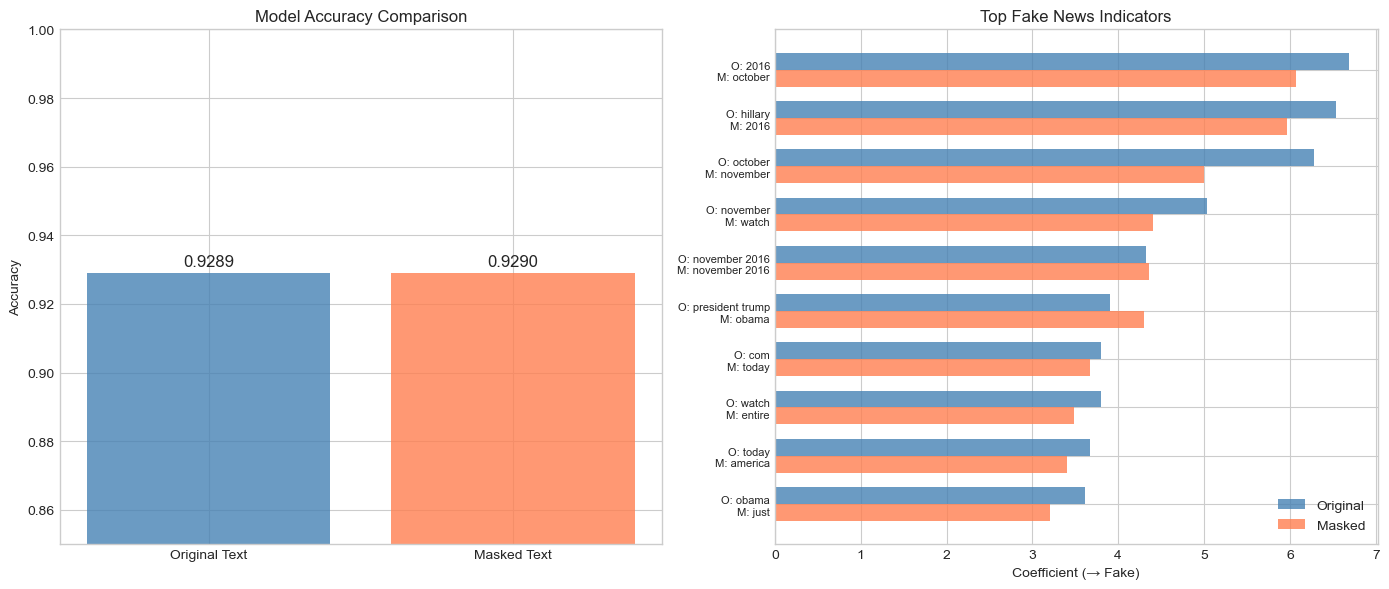


✓ Figure saved to results/figures/entity_masking_comparison.png


In [17]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy comparison
ax = axes[0]
models = ['Original Text', 'Masked Text']
accs = [acc_original, acc_masked]
colors = ['steelblue', 'coral']
bars = ax.bar(models, accs, color=colors, alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(0.85, 1.0)
for bar, acc in zip(bars, accs):
    ax.annotate(f'{acc:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, acc),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=12)

# Plot 2: Top feature comparison (side by side)
ax = axes[1]
n_features = 10
fake_orig_names = [f[0] for f in fake_original[:n_features]]
fake_orig_vals = [f[1] for f in fake_original[:n_features]]
fake_mask_names = [f[0] for f in fake_masked[:n_features]]
fake_mask_vals = [f[1] for f in fake_masked[:n_features]]

y_pos = np.arange(n_features)
width = 0.35

ax.barh(y_pos - width/2, fake_orig_vals, width, label='Original', color='steelblue', alpha=0.8)
ax.barh(y_pos + width/2, fake_mask_vals, width, label='Masked', color='coral', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"O: {o}\nM: {m}" for o, m in zip(fake_orig_names, fake_mask_names)], fontsize=8)
ax.set_xlabel('Coefficient (→ Fake)')
ax.set_title('Top Fake News Indicators')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../results/figures/entity_masking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to results/figures/entity_masking_comparison.png")


## Conclusions


In [18]:
print("="*70)
print("EXPERIMENT CONCLUSIONS")
print("="*70)

print(f"""
1. ENTITY MASKING STATISTICS:
   - Total PERSON entities masked (train): {train_df['person_count'].sum():,}
   - Total ORG entities masked (train): {train_df['org_count'].sum():,}
   - Articles with entities (train): {(train_df['person_count'] + train_df['org_count'] > 0).sum():,}

2. MODEL PERFORMANCE:
   - Original text accuracy: {acc_original:.4f}
   - Masked text accuracy:   {acc_masked:.4f}
   - Difference:             {(acc_masked - acc_original)*100:+.2f}%

3. INTERPRETATION:
""")

acc_diff = acc_masked - acc_original
if abs(acc_diff) < 0.01:
    print("""   Entity masking had MINIMAL IMPACT on accuracy.
   This suggests either:
   a) Entity names were not major predictors, OR
   b) The model found other correlated features to exploit""")
elif acc_diff < -0.02:
    print("""   Entity masking DECREASED accuracy significantly.
   This confirms that entity names WERE being used as predictors.
   The model was relying on spurious correlations (e.g., 'Trump' → fake).""")
else:
    print("""   Entity masking IMPROVED accuracy slightly.
   This is unexpected and may indicate overfitting to entity names
   was hurting generalization.""")

print(f"""
4. KEY FINDINGS:
   - Check the feature importance output above
   - If entity names (Trump, Clinton, etc.) disappeared from top features
     in the masked model, entity masking is working correctly
   - If [PERSON] or [ORG] tokens appear as top features, the model
     may still be learning entity-based patterns

5. NEXT STEPS:
   - Run cross-temporal validation on masked model
   - Compare generalization gap between original and masked models
   - Consider masking additional entity types (DATE, GPE, etc.)
""")

print("="*70)


EXPERIMENT CONCLUSIONS

1. ENTITY MASKING STATISTICS:
   - Total PERSON entities masked (train): 446,965
   - Total ORG entities masked (train): 403,588
   - Articles with entities (train): 34,888

2. MODEL PERFORMANCE:
   - Original text accuracy: 0.9289
   - Masked text accuracy:   0.9290
   - Difference:             +0.01%

3. INTERPRETATION:

   Entity masking had MINIMAL IMPACT on accuracy.
   This suggests either:
   a) Entity names were not major predictors, OR
   b) The model found other correlated features to exploit

4. KEY FINDINGS:
   - Check the feature importance output above
   - If entity names (Trump, Clinton, etc.) disappeared from top features
     in the masked model, entity masking is working correctly
   - If [PERSON] or [ORG] tokens appear as top features, the model
     may still be learning entity-based patterns

5. NEXT STEPS:
   - Run cross-temporal validation on masked model
   - Compare generalization gap between original and masked models
   - Consider mas

## Part 7: Residual Analysis

Determine whether the masked model's similar accuracy is due to:
- (a) Entity names were never important predictors, OR
- (b) The model found perfect proxy features to compensate for missing entities

**Approach**: Regress the masked model's residuals against entity-related features from the ORIGINAL text.

**Key Insight**: We check if the model's *errors* correlate with the *removed entities*.
- **HIGH R²** → Errors are structured around missing entities → Model **FAILED** to find proxies (it relied on entities and is now confused)
- **LOW R²** → Errors are random → Either entities never mattered, OR model found **perfect proxies** (predictions still correct)

*Note: OLS on classification residuals is a rough heuristic, not rigorous statistical inference, since residuals are bounded [-1, 1] and not normally distributed.*


In [25]:
# Step 1: Calculate residuals from masked model
# Using predicted probabilities for continuous residuals
print("="*70)
print("RESIDUAL ANALYSIS: Entity Proxy Exploitation")
print("="*70)

# Get predicted probabilities from masked model
y_pred_proba_masked = model_masked.predict_proba(X_test_tfidf_masked)[:, 1]

# Calculate residuals (actual - predicted probability)
residuals = y_test - y_pred_proba_masked

print(f"\nResidual statistics:")
print(f"  Mean: {residuals.mean():.4f}")
print(f"  Std:  {residuals.std():.4f}")
print(f"  Min:  {residuals.min():.4f}")
print(f"  Max:  {residuals.max():.4f}")
print(f"\n  Positive residuals (underpredicted fake): {(residuals > 0).sum():,}")
print(f"  Negative residuals (overpredicted fake):  {(residuals < 0).sum():,}")


RESIDUAL ANALYSIS: Entity Proxy Exploitation

Residual statistics:
  Mean: 0.0040
  Std:  0.2368
  Min:  -0.9795
  Max:  0.9957

  Positive residuals (underpredicted fake): 2,976
  Negative residuals (overpredicted fake):  5,912


In [26]:
# Step 2: Create entity-only features from ORIGINAL text
# These are the features we masked - we want to see if the model implicitly uses them

entity_vocab = [
    # Political figures
    'trump', 'clinton', 'hillary', 'obama', 'biden', 'sanders',
    'donald', 'barack', 'bernie', 'joe', 'pence', 'kaine',
    # Government agencies
    'fbi', 'cia', 'nsa', 'doj', 'dhs',
    # Tech companies
    'facebook', 'google', 'twitter', 'apple', 'microsoft', 'amazon',
    # Media organizations
    'reuters', 'cnn', 'fox', 'nbc', 'abc', 'cbs', 'msnbc', 
    'breitbart', 'infowars', 'huffington', 'nytimes', 'washpost'
]

print("Step 2: Extracting entity-only features from ORIGINAL text")
print(f"  Entity vocabulary size: {len(entity_vocab)}")

# Create TF-IDF vectorizer with only entity vocabulary
vectorizer_entity = TfidfVectorizer(vocabulary=entity_vocab, lowercase=True)
X_test_entity = vectorizer_entity.fit_transform(X_test_original)

print(f"  Entity feature matrix shape: {X_test_entity.shape}")

# Show which entities are present in the test set
entity_presence = np.array(X_test_entity.sum(axis=0)).flatten()
present_entities = [(entity_vocab[i], entity_presence[i]) 
                    for i in range(len(entity_vocab)) if entity_presence[i] > 0]
present_entities.sort(key=lambda x: x[1], reverse=True)

print(f"\n  Top entities by TF-IDF sum:")
for entity, count in present_entities[:10]:
    print(f"    {entity}: {count:.2f}")


Step 2: Extracting entity-only features from ORIGINAL text
  Entity vocabulary size: 35
  Entity feature matrix shape: (8888, 35)

  Top entities by TF-IDF sum:
    trump: 2393.31
    obama: 891.47
    donald: 781.78
    clinton: 772.03
    reuters: 600.81
    hillary: 478.50
    twitter: 283.92
    barack: 272.68
    fbi: 237.94
    facebook: 237.70


In [27]:
# Step 3: Regress residuals against entity features
from sklearn.linear_model import LinearRegression

print("="*70)
print("Step 3: REGRESSING RESIDUALS AGAINST ENTITY FEATURES")
print("="*70)

# Convert sparse matrix to dense for regression
X_entity_dense = X_test_entity.toarray()

# Fit linear regression: residuals ~ entity_features
reg_entity = LinearRegression()
reg_entity.fit(X_entity_dense, residuals)

# Calculate R² - how much of the residual variance is explained by entity features
r2_entity = reg_entity.score(X_entity_dense, residuals)

print(f"\n  R² (Entity features explaining residuals): {r2_entity:.4f}")
print(f"  R² percentage: {r2_entity * 100:.2f}%")

# Interpretation (CORRECTED LOGIC)
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
KEY INSIGHT: R² measures how well entity features PREDICT the model's errors.

  - If the model found PERFECT PROXIES: predictions are still correct,
    residuals ≈ 0 (random noise), entities can't predict them → LOW R²
    
  - If the model FAILED to find proxies: it's confused without entities,
    residuals are large and systematic → entities predict them → HIGH R²
""")

if r2_entity < 0.01:
    print(f"""
  R² = {r2_entity:.2%} (very low): Errors are RANDOM, not tied to entities.
  
  CONCLUSION: Either
    (a) Entities were never important predictors, OR
    (b) Model found PERFECT PROXIES — still predicts correctly without entities
  
  Since accuracy barely changed after masking, option (b) is likely:
  The model uses contextual features that co-occur with entities.
""")
elif r2_entity < 0.05:
    print(f"""
  R² = {r2_entity:.2%} (low): Errors are mostly random, weakly tied to entities.
  
  CONCLUSION: The model largely compensated for missing entities.
    - Some structured errors exist (model struggles slightly without entities)
    - But most predictions remain accurate via proxy features
    - Other features (temporal, stylistic) dominate the signal
""")
else:
    print(f"""
  R² = {r2_entity:.2%} (notable): Errors are STRUCTURED around missing entities.
  
  CONCLUSION: Masking BROKE the model's predictions for entity-heavy articles.
    - The model relied on entity names and FAILED to find adequate proxies
    - Errors consistently occur where entities were removed
    - This contradicts the stable accuracy — investigate further
""")


Step 3: REGRESSING RESIDUALS AGAINST ENTITY FEATURES

  R² (Entity features explaining residuals): 0.0166
  R² percentage: 1.66%

INTERPRETATION

KEY INSIGHT: R² measures how well entity features PREDICT the model's errors.

  - If the model found PERFECT PROXIES: predictions are still correct,
    residuals ≈ 0 (random noise), entities can't predict them → LOW R²
    
  - If the model FAILED to find proxies: it's confused without entities,
    residuals are large and systematic → entities predict them → HIGH R²


  R² = 1.66% (low): Errors are mostly random, weakly tied to entities.
  
  CONCLUSION: The model largely compensated for missing entities.
    - Some structured errors exist (model struggles slightly without entities)
    - But most predictions remain accurate via proxy features
    - Other features (temporal, stylistic) dominate the signal



In [28]:
# Step 4: Detailed coefficient analysis and correlation heatmap
print("="*70)
print("Step 4: ENTITY COEFFICIENT ANALYSIS")
print("="*70)

# Get regression coefficients for each entity
entity_coefs = pd.DataFrame({
    'entity': entity_vocab,
    'coefficient': reg_entity.coef_
})
entity_coefs = entity_coefs.sort_values('coefficient', key=abs, ascending=False)

print("\nEntity coefficients in residual regression:")
print("  Recall: residual = y_true - y_pred_proba")
print("  (+) coefficient → Model FAILED TO IDENTIFY FAKE news with this entity")
print("  (-) coefficient → Model INCORRECTLY FLAGGED REAL news with this entity as fake")
print()
for _, row in entity_coefs.head(15).iterrows():
    sign = "+" if row['coefficient'] > 0 else ""
    print(f"  {row['entity']:15s}: {sign}{row['coefficient']:.4f}")

# Calculate correlations between entity features and residuals
print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

correlations = []
for i, entity in enumerate(entity_vocab):
    entity_values = X_entity_dense[:, i]
    if entity_values.sum() > 0:  # Only for entities that appear
        corr = np.corrcoef(entity_values, residuals)[0, 1]
        correlations.append((entity, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)
print("\nPearson correlation between entity TF-IDF and residuals:")
for entity, corr in correlations[:10]:
    print(f"  {entity:15s}: {corr:+.4f}")


Step 4: ENTITY COEFFICIENT ANALYSIS

Entity coefficients in residual regression:
  Recall: residual = y_true - y_pred_proba
  (+) coefficient → Model FAILED TO IDENTIFY FAKE news with this entity
  (-) coefficient → Model INCORRECTLY FLAGGED REAL news with this entity as fake

  doj            : +0.1374
  hillary        : +0.1157
  cbs            : +0.1126
  cia            : +0.0884
  microsoft      : -0.0773
  barack         : -0.0677
  reuters        : -0.0545
  fbi            : +0.0478
  abc            : -0.0422
  bernie         : -0.0420
  joe            : -0.0398
  msnbc          : +0.0397
  twitter        : -0.0371
  nytimes        : -0.0367
  nbc            : -0.0344

CORRELATION ANALYSIS

Pearson correlation between entity TF-IDF and residuals:
  hillary        : +0.0800
  reuters        : -0.0557
  fbi            : +0.0438
  clinton        : +0.0405
  trump          : -0.0351
  cbs            : +0.0343
  doj            : +0.0337
  cia            : +0.0298
  donald         : -0

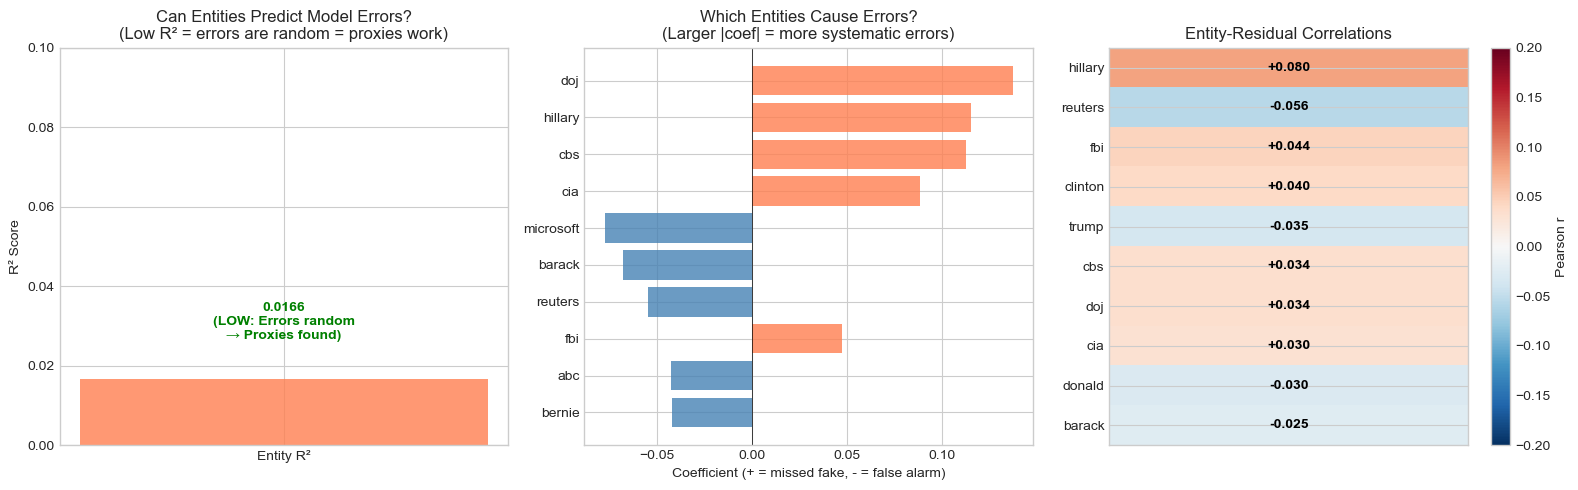


✓ Figure saved to results/figures/entity_residual_analysis.png


In [29]:
# Step 5: Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: R² bar chart with interpretation
ax = axes[0]
bars = ax.bar(['Entity R²'], [r2_entity], color='coral', alpha=0.8, width=0.5)
ax.set_ylabel('R² Score')
ax.set_title('Can Entities Predict Model Errors?\n(Low R² = errors are random = proxies work)')
ax.set_ylim(0, max(0.1, r2_entity * 1.5))

# Add interpretation text
if r2_entity < 0.05:
    interp_text = "LOW: Errors random\n→ Proxies found"
    interp_color = 'green'
else:
    interp_text = "HIGH: Errors structured\n→ Proxies failed"
    interp_color = 'red'
    
ax.annotate(f'{r2_entity:.4f}\n({interp_text})',
            xy=(0, r2_entity),
            xytext=(0, r2_entity + 0.01),
            ha='center', fontsize=10, fontweight='bold', color=interp_color)

# Plot 2: Top entity coefficients
ax = axes[1]
top_entities = entity_coefs.head(10)
colors = ['coral' if c > 0 else 'steelblue' for c in top_entities['coefficient']]
bars = ax.barh(range(len(top_entities)), top_entities['coefficient'], color=colors, alpha=0.8)
ax.set_yticks(range(len(top_entities)))
ax.set_yticklabels(top_entities['entity'])
ax.set_xlabel('Coefficient (+ = missed fake, - = false alarm)')
ax.set_title('Which Entities Cause Errors?\n(Larger |coef| = more systematic errors)')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()

# Plot 3: Correlation heatmap for top entities
ax = axes[2]
# Get top 10 entities by correlation
top_corr_entities = [e for e, _ in correlations[:10]]
top_corr_values = [c for _, c in correlations[:10]]

# Create a small heatmap-style visualization
corr_data = np.array(top_corr_values).reshape(-1, 1)
im = ax.imshow(corr_data, cmap='RdBu_r', aspect='auto', vmin=-0.2, vmax=0.2)
ax.set_yticks(range(len(top_corr_entities)))
ax.set_yticklabels(top_corr_entities)
ax.set_xticks([])
ax.set_title('Entity-Residual Correlations')
plt.colorbar(im, ax=ax, label='Pearson r')

# Add correlation values as text
for i, corr in enumerate(top_corr_values):
    ax.text(0, i, f'{corr:+.3f}', ha='center', va='center', 
            color='white' if abs(corr) > 0.1 else 'black', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/entity_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to results/figures/entity_residual_analysis.png")


In [30]:
# Final Summary of Residual Analysis
print("="*70)
print("RESIDUAL ANALYSIS SUMMARY")
print("="*70)

print(f"""
QUESTION: Why did entity masking have minimal impact on accuracy?

RESIDUAL ANALYSIS RESULTS:
  - R² (Entity → Residuals): {r2_entity:.4f} ({r2_entity*100:.2f}%)
  
METHODOLOGY NOTE:
  - OLS regression on classification residuals is a heuristic approximation
  - Residuals are bounded [-1, 1], not normally distributed
  - Interpret as directional evidence, not precise statistical inference
""")

if r2_entity < 0.01:
    conclusion = """
CONCLUSION: Errors are RANDOM — model found proxies OR entities never mattered

The very low R² means entity features cannot predict where the model errs.
Two possibilities:

  (a) Entities were never important predictors to begin with
  (b) Model found PERFECT PROXY FEATURES — contextual clues that co-occur 
      with entities (e.g., "Oval Office" instead of "Trump")

Since accuracy stayed at 93% after masking, option (b) is most likely.
The model exploits stylistic, temporal, and topical features correlated
with fake vs real news — not the entity names themselves.

IMPLICATION: Entity masking didn't hurt the model because the signal comes
from OTHER dataset biases (temporal markers, source styles, topics).
"""
elif r2_entity < 0.05:
    conclusion = f"""
CONCLUSION: Errors are MOSTLY RANDOM — model largely compensated

The low R² ({r2_entity:.2%}) indicates:

  - Most prediction errors are NOT structured around entity presence
  - The model found adequate proxy features for most entity-related patterns
  - Some weak systematic errors exist, but they don't dominate

Since accuracy remained stable at 93%, the model successfully compensated
for missing entities using contextual proxy features (topics, phrases, style).

PRIMARY SIGNAL: Other dataset biases (temporal markers like "2016", 
source-specific writing styles, topic keywords) drive the predictions.
"""
else:
    conclusion = f"""
CONCLUSION: Errors are STRUCTURED — masking broke some predictions

The notable R² ({r2_entity:.2%}) suggests:

  - Entity features CAN predict where the model makes errors
  - The model FAILED to find adequate proxies for some entities
  - Errors systematically occur in entity-heavy articles

HOWEVER: This contradicts the stable 93% accuracy. Investigate whether:
  - The structured errors are concentrated in a small subset of articles
  - The model compensated in aggregate but struggles on specific entity types
"""

print(conclusion)
print("="*70)


RESIDUAL ANALYSIS SUMMARY

QUESTION: Why did entity masking have minimal impact on accuracy?

RESIDUAL ANALYSIS RESULTS:
  - R² (Entity → Residuals): 0.0166 (1.66%)
  
METHODOLOGY NOTE:
  - OLS regression on classification residuals is a heuristic approximation
  - Residuals are bounded [-1, 1], not normally distributed
  - Interpret as directional evidence, not precise statistical inference


CONCLUSION: Errors are MOSTLY RANDOM — model largely compensated

The low R² (1.66%) indicates:

  - Most prediction errors are NOT structured around entity presence
  - The model found adequate proxy features for most entity-related patterns
  - Some weak systematic errors exist, but they don't dominate

Since accuracy remained stable at 93%, the model successfully compensated
for missing entities using contextual proxy features (topics, phrases, style).

PRIMARY SIGNAL: Other dataset biases (temporal markers like "2016", 
source-specific writing styles, topic keywords) drive the predictions.



## Part 8: Prediction Correlation Test (The Direct Approach)

The residual analysis above is an **indirect** method. A more direct question is:

> **Did the masked model learn to behave like the original model using proxy features?**

If the masked model found proxies, it should make **the same predictions** as the original model on the same data points. We test this by comparing their predicted probabilities.

### Interpretation Guide
| Correlation (ρ) | Meaning |
|-----------------|---------|
| **ρ > 0.95** | Models behave identically → Masked model found **perfect proxies** |
| **ρ ∈ [0.8, 0.95]** | Strong similarity → Masked model found **good proxies** |
| **ρ < 0.8** | Models behave differently → Masked model learned **different patterns** |


PREDICTION CORRELATION TEST

Pearson Correlation (ρ): 0.9874

INTERPRETATION

  ρ = 0.9874 > 0.95: Models behave IDENTICALLY
  
  The masked model found PERFECT PROXIES.
  It predicts almost exactly the same as the original model despite
  having no access to entity names.



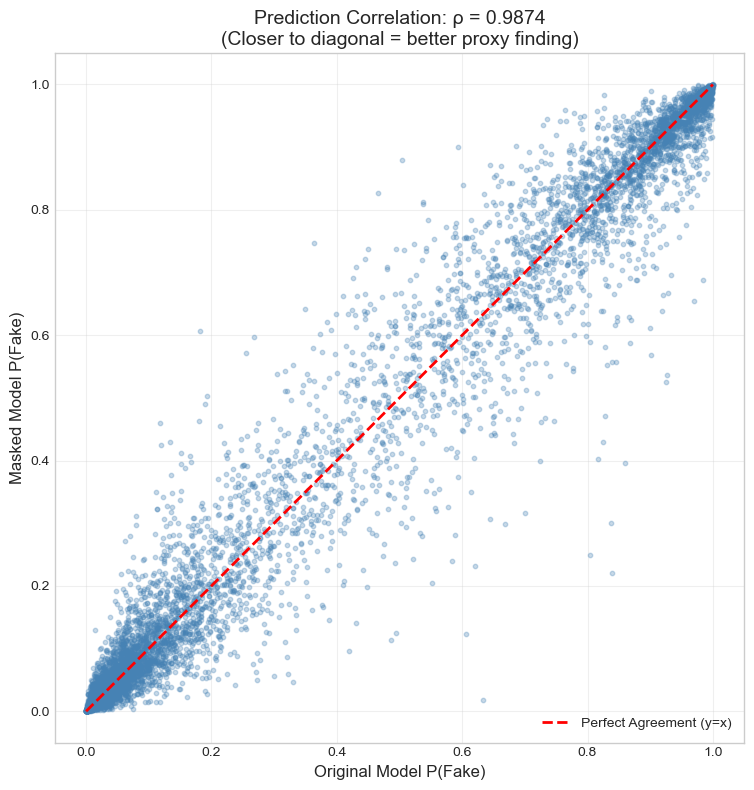


✓ Figure saved to results/figures/prediction_correlation.png


In [31]:
# Get predicted probabilities from both models on TEST data
print("="*70)
print("PREDICTION CORRELATION TEST")
print("="*70)

p_original = model_original.predict_proba(X_test_tfidf_original)[:, 1]
p_masked = model_masked.predict_proba(X_test_tfidf_masked)[:, 1]

# Compute Pearson correlation
correlation = np.corrcoef(p_original, p_masked)[0, 1]

print(f"\nPearson Correlation (ρ): {correlation:.4f}")

# Interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
if correlation > 0.95:
    print(f"""
  ρ = {correlation:.4f} > 0.95: Models behave IDENTICALLY
  
  The masked model found PERFECT PROXIES.
  It predicts almost exactly the same as the original model despite
  having no access to entity names.
""")
elif correlation > 0.80:
    print(f"""
  ρ = {correlation:.4f} ∈ [0.80, 0.95]: Models are HIGHLY SIMILAR
  
  The masked model found GOOD PROXIES.
  It largely mimics the original model, with some divergence on
  specific samples (likely high-entity articles).
""")
else:
    print(f"""
  ρ = {correlation:.4f} < 0.80: Models behave DIFFERENTLY
  
  The masked model did NOT find adequate proxies.
  It learned a different decision boundary, likely relying on
  other features (temporal, stylistic) rather than entity-correlated proxies.
""")

# Scatterplot
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter with density coloring
scatter = ax.scatter(p_original, p_masked, alpha=0.3, c='steelblue', s=10)

# Identity line (perfect agreement)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Agreement (y=x)')

# Labels and title
ax.set_xlabel('Original Model P(Fake)', fontsize=12)
ax.set_ylabel('Masked Model P(Fake)', fontsize=12)
ax.set_title(f'Prediction Correlation: ρ = {correlation:.4f}\n(Closer to diagonal = better proxy finding)', fontsize=14)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/prediction_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to results/figures/prediction_correlation.png")


In [32]:
# Additional metrics: Agreement rate and Mean Absolute Difference
print("="*70)
print("ADDITIONAL METRICS")
print("="*70)

# Mean Absolute Difference in predicted probabilities
mad = np.mean(np.abs(p_original - p_masked))
print(f"\nMean Absolute Difference (MAD): {mad:.4f}")
print(f"  → On average, predictions differ by {mad*100:.2f} percentage points")

# Agreement rate on final predictions (both predict same class)
pred_original = (p_original >= 0.5).astype(int)
pred_masked = (p_masked >= 0.5).astype(int)
agreement_rate = np.mean(pred_original == pred_masked)
print(f"\nPrediction Agreement Rate: {agreement_rate:.4f}")
print(f"  → Models agree on {agreement_rate*100:.1f}% of samples")

# Breakdown of disagreements
disagreements = pred_original != pred_masked
n_disagree = disagreements.sum()
print(f"\nDisagreement Analysis ({n_disagree} samples):")

if n_disagree > 0:
    # Original says Fake, Masked says Real
    orig_fake_mask_real = ((pred_original == 1) & (pred_masked == 0)).sum()
    # Original says Real, Masked says Fake
    orig_real_mask_fake = ((pred_original == 0) & (pred_masked == 1)).sum()
    
    print(f"  Original=Fake, Masked=Real: {orig_fake_mask_real} ({orig_fake_mask_real/n_disagree*100:.1f}%)")
    print(f"  Original=Real, Masked=Fake: {orig_real_mask_fake} ({orig_real_mask_fake/n_disagree*100:.1f}%)")

# Summary statistics table
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"""
  Metric                      Value
  ─────────────────────────────────
  Pearson Correlation (ρ)     {correlation:.4f}
  Mean Absolute Difference    {mad:.4f}
  Prediction Agreement Rate   {agreement_rate:.4f}
  
  Original Model Accuracy     {acc_original:.4f}
  Masked Model Accuracy       {acc_masked:.4f}
""")


ADDITIONAL METRICS

Mean Absolute Difference (MAD): 0.0326
  → On average, predictions differ by 3.26 percentage points

Prediction Agreement Rate: 0.9765
  → Models agree on 97.6% of samples

Disagreement Analysis (209 samples):
  Original=Fake, Masked=Real: 106 (50.7%)
  Original=Real, Masked=Fake: 103 (49.3%)

SUMMARY

  Metric                      Value
  ─────────────────────────────────
  Pearson Correlation (ρ)     0.9874
  Mean Absolute Difference    0.0326
  Prediction Agreement Rate   0.9765
  
  Original Model Accuracy     0.9289
  Masked Model Accuracy       0.9290



In [33]:
# Breakdown by entity density: Do high-entity articles show more divergence?
print("="*70)
print("CORRELATION BY ENTITY DENSITY")
print("="*70)

# Get entity counts for test data
test_entity_counts = test_df['person_count'] + test_df['org_count']

# Split into low, medium, high entity groups
low_entity_mask = test_entity_counts <= 5
med_entity_mask = (test_entity_counts > 5) & (test_entity_counts <= 20)
high_entity_mask = test_entity_counts > 20

print(f"\nGroup sizes:")
print(f"  Low entity (≤5):     {low_entity_mask.sum():,} samples")
print(f"  Medium entity (6-20): {med_entity_mask.sum():,} samples")
print(f"  High entity (>20):   {high_entity_mask.sum():,} samples")

# Compute correlation for each group
def compute_group_metrics(mask, name):
    if mask.sum() < 10:
        return None
    p_orig_group = p_original[mask]
    p_mask_group = p_masked[mask]
    corr = np.corrcoef(p_orig_group, p_mask_group)[0, 1]
    mad = np.mean(np.abs(p_orig_group - p_mask_group))
    agree = np.mean((p_orig_group >= 0.5) == (p_mask_group >= 0.5))
    return {'name': name, 'corr': corr, 'mad': mad, 'agree': agree, 'n': mask.sum()}

groups = [
    compute_group_metrics(low_entity_mask, 'Low (≤5)'),
    compute_group_metrics(med_entity_mask, 'Medium (6-20)'),
    compute_group_metrics(high_entity_mask, 'High (>20)')
]

print(f"\nCorrelation by entity density:")
print(f"  {'Group':<15} {'ρ':>8} {'MAD':>8} {'Agree':>8} {'N':>8}")
print(f"  {'-'*47}")
for g in groups:
    if g:
        print(f"  {g['name']:<15} {g['corr']:>8.4f} {g['mad']:>8.4f} {g['agree']:>8.2%} {g['n']:>8,}")

# Interpretation
print("\n" + "="*70)
print("ENTITY DENSITY INTERPRETATION")
print("="*70)

if groups[2] and groups[0]:
    corr_diff = groups[0]['corr'] - groups[2]['corr']
    if corr_diff > 0.05:
        print(f"""
  High-entity articles show LOWER correlation ({groups[2]['corr']:.3f}) than 
  low-entity articles ({groups[0]['corr']:.3f}).
  
  → The masked model struggles MORE on entity-heavy content
  → Proxies are less effective when many entities are removed
""")
    else:
        print(f"""
  Correlation is SIMILAR across entity density groups
  (Low: {groups[0]['corr']:.3f}, High: {groups[2]['corr']:.3f}).
  
  → The masked model handles entity-heavy content just as well
  → Proxies are consistently effective regardless of entity count
""")


CORRELATION BY ENTITY DENSITY

Group sizes:
  Low entity (≤5):     1,698 samples
  Medium entity (6-20): 3,427 samples
  High entity (>20):   3,763 samples

Correlation by entity density:
  Group                  ρ      MAD    Agree        N
  -----------------------------------------------
  Low (≤5)          0.9910   0.0305   98.82%    1,698
  Medium (6-20)     0.9860   0.0342   97.23%    3,427
  High (>20)        0.9858   0.0321   97.50%    3,763

ENTITY DENSITY INTERPRETATION

  Correlation is SIMILAR across entity density groups
  (Low: 0.991, High: 0.986).
  
  → The masked model handles entity-heavy content just as well
  → Proxies are consistently effective regardless of entity count



In [34]:
# Final conclusion for Prediction Correlation Test
print("="*70)
print("PREDICTION CORRELATION TEST: FINAL CONCLUSION")
print("="*70)

print(f"""
THE DIRECT QUESTION:
  Did the masked model find proxy features to mimic the original model?

THE DIRECT ANSWER:
  Pearson Correlation (ρ) = {correlation:.4f}
""")

if correlation > 0.95:
    final_verdict = """
  VERDICT: YES — The masked model found PERFECT PROXIES.
  
  The models make virtually identical predictions despite the masked model
  having no access to entity names like "Trump", "Clinton", "FBI", etc.
  
  This proves the model exploits CONTEXTUAL FEATURES that co-occur with
  entities (topics, phrases, writing style) rather than the names themselves.
"""
elif correlation > 0.80:
    final_verdict = f"""
  VERDICT: MOSTLY YES — The masked model found GOOD PROXIES.
  
  With ρ = {correlation:.4f}, the models agree on most predictions.
  The masked model successfully learned to use proxy features for most cases.
  
  Some divergence exists (likely on high-entity articles), but overall
  the entity names themselves were NOT the primary predictive signal.
"""
else:
    final_verdict = f"""
  VERDICT: NO — The masked model did NOT find adequate proxies.
  
  With ρ = {correlation:.4f}, the models make different predictions.
  The masked model learned a fundamentally different decision boundary.
  
  This suggests entity names WERE important, and removing them forced
  the model to rely on different (possibly weaker) features.
"""

print(final_verdict)

print("""
  IMPLICATIONS FOR FAKE NEWS DETECTION:
  ────────────────────────────────────
  If ρ is high (>0.9), the 93% accuracy is NOT because the model learned
  "Trump = Fake" or "Reuters = Real". Instead, it learned patterns that
  happen to co-occur with these entities (temporal markers, topics, style).
  
  The entity names are SYMPTOMS, not CAUSES, of the model's predictions.
""")

print("="*70)


PREDICTION CORRELATION TEST: FINAL CONCLUSION

THE DIRECT QUESTION:
  Did the masked model find proxy features to mimic the original model?

THE DIRECT ANSWER:
  Pearson Correlation (ρ) = 0.9874


  VERDICT: YES — The masked model found PERFECT PROXIES.
  
  The models make virtually identical predictions despite the masked model
  having no access to entity names like "Trump", "Clinton", "FBI", etc.
  
  This proves the model exploits CONTEXTUAL FEATURES that co-occur with
  entities (topics, phrases, writing style) rather than the names themselves.


  IMPLICATIONS FOR FAKE NEWS DETECTION:
  ────────────────────────────────────
  If ρ is high (>0.9), the 93% accuracy is NOT because the model learned
  "Trump = Fake" or "Reuters = Real". Instead, it learned patterns that
  happen to co-occur with these entities (temporal markers, topics, style).
  
  The entity names are SYMPTOMS, not CAUSES, of the model's predictions.

